# Intelligent Decision Support System for USA Stores
## Relatório de Investigação: Data Science & Forecasting (W1-W4)
**Objetivo:** Desenvolver um sistema robusto de previsão de vendas para 4 lojas (Baltimore, Lancaster, Philadelphia, Richmond) para suporte à decisão de gestão semanal

### Setup (Imports)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from statsmodels.graphics.tsaplots import plot_acf
# Configurações visuais
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_context("notebook", font_scale=1.2)

### Data Understanding

In [4]:
# Extrair a pasta de dados para o Colab
import zipfile
import os
with zipfile.ZipFile('data.zip', 'r') as zip_ref:
    zip_ref.extractall('.')
print("Estrutura de pastas 'data/' restaurada com sucesso!")

Estrutura de pastas 'data/' restaurada com sucesso!


Dataset Baltimore: 714 registos diários.


,Date,Num_Employees,Num_Customers,Pct_On_Sale,TouristEvent,Sales
0,2012-07-01,20,170,10.11,No,40669
1,2012-07-02,12,152,8.78,No,35360
2,2012-07-03,10,185,9.09,No,40741
3,2012-07-04,16,182,10.23,No,33871
4,2012-07-05,19,155,9.95,No,36880


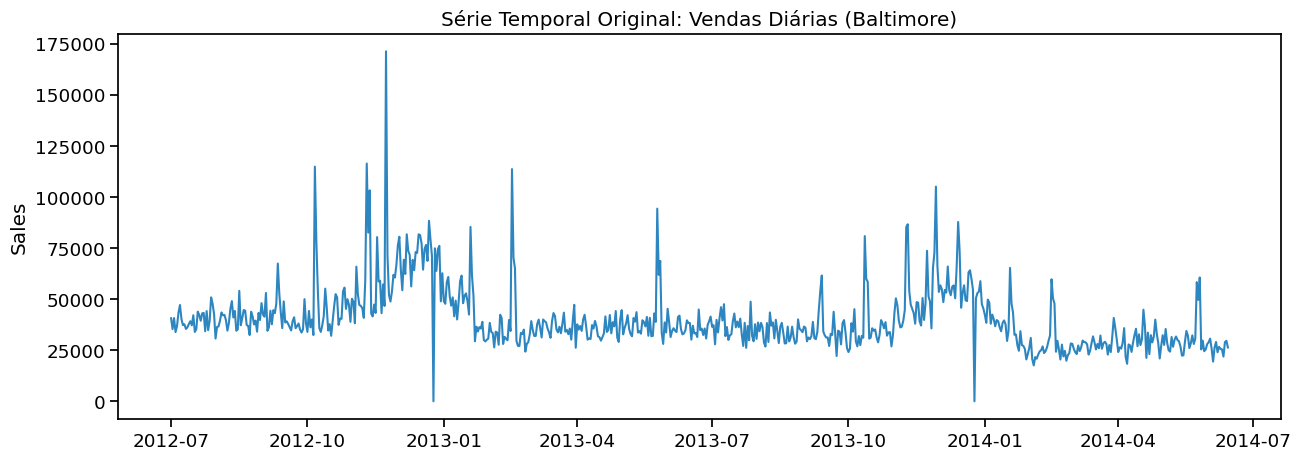

In [5]:
# Vamos analisar Baltimore como representativa
df_balt = pd.read_csv('data/raw/baltimore.csv', parse_dates=['Date'])
print(f"Dataset Baltimore: {df_balt.shape[0]} registos diários.")
display(df_balt.head())
# Visualização da Série Temporal Original
plt.figure(figsize=(15, 5))
plt.plot(df_balt['Date'], df_balt['Sales'], color='#2E86C1')
plt.title('Série Temporal Original: Vendas Diárias (Baltimore)')
plt.ylabel('Sales')
plt.show()

### Justificação da Limpeza (W2)
Durante a análise qualitativa, detetámos anomalias (vendas sem clientes) e picos extremos.
Implementámos em `src/preparation.py` uma técnica de **Clipping Estatístico (Quantis 1% e 99%)** para evitar que outliers distorçam a aprendizagem dos modelos de Forecasting.

### Engenharia de Features (W3)

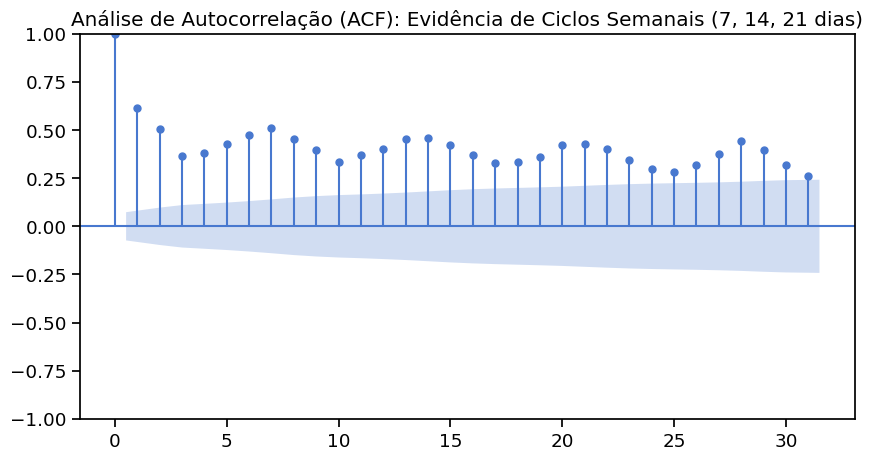

In [6]:
# Gráfico de Autocorrelação (ACF)
plt.figure(figsize=(10, 5))
plot_acf(df_balt['Sales'].dropna(), lags=31, ax=plt.gca())
plt.title('Análise de Autocorrelação (ACF): Evidência de Ciclos Semanais (7, 14, 21 dias)')
plt.show()

 Isto justifica o porquê de usarmos Lags de 7 dias (Sazonalidade semanal)

### Resultados Comparativos (W4)

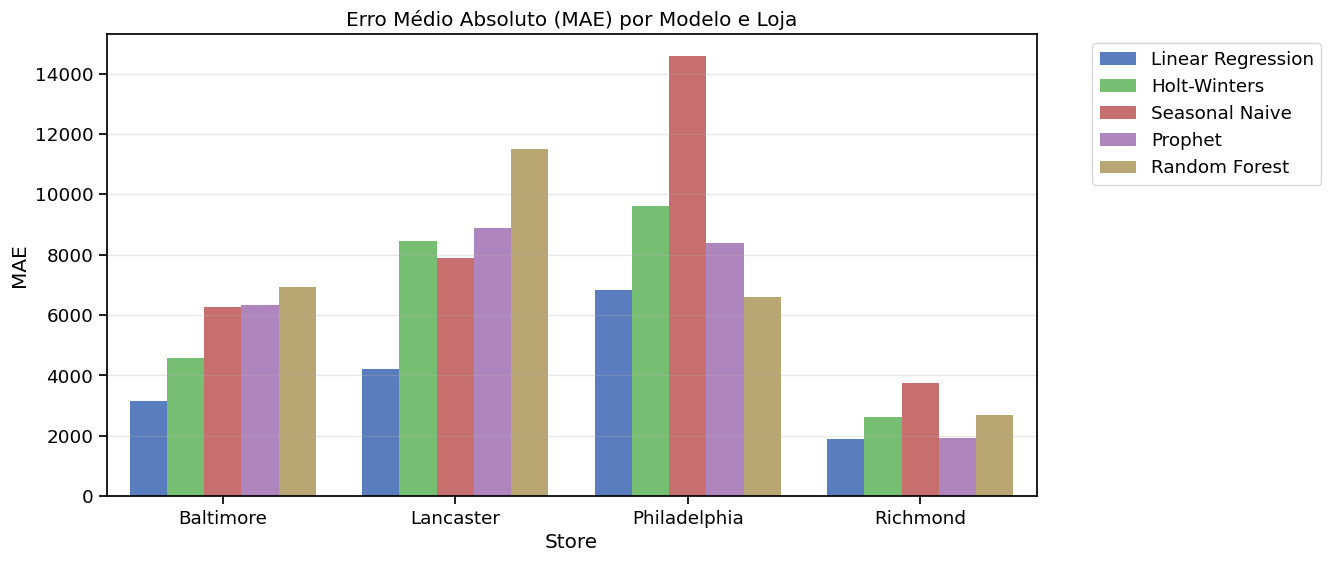

,Store,Model,MAE,RMSE,MAPE
0,Baltimore,Linear Regression,3153.627802,4221.074545,11.389166
1,Baltimore,Holt-Winters,4593.809744,6944.985744,14.835414
2,Baltimore,Seasonal Naive,6277.477971,9644.063194,21.181607
3,Baltimore,Prophet,6332.241495,7318.337555,21.626350
4,Baltimore,Random Forest,6921.265431,8065.149107,26.006460
5,Lancaster,Linear Regression,4206.453651,5264.397064,11.969637
6,Lancaster,Seasonal Naive,7907.073913,12539.602627,20.979663
7,Lancaster,Holt-Winters,8463.550998,11435.497507,21.913654
8,Lancaster,Prophet,8867.972711,10170.308843,24.238410
9,Lancaster,Random Forest,11489.166759,12332.246528,34.320117


In [7]:
# Carregar o relatório Final gerado pelo main_pipeline.py
try:
    results = pd.read_csv('data/processed/final_model_report.csv')

    # Gráfico de Barras por MAE
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Store', y='MAE', hue='Model', data=results)
    plt.title('Erro Médio Absoluto (MAE) por Modelo e Loja')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    display(results.sort_values(by=['Store', 'MAE']))
except FileNotFoundError:
    print("Aviso: Corre o 'main_pipeline.py' localmente para gerar o ficheiro final_model_report.csv.")

### Visualização da Previsão

### Exemplo de Previsão Final (Last 30 Days Test Set) ###


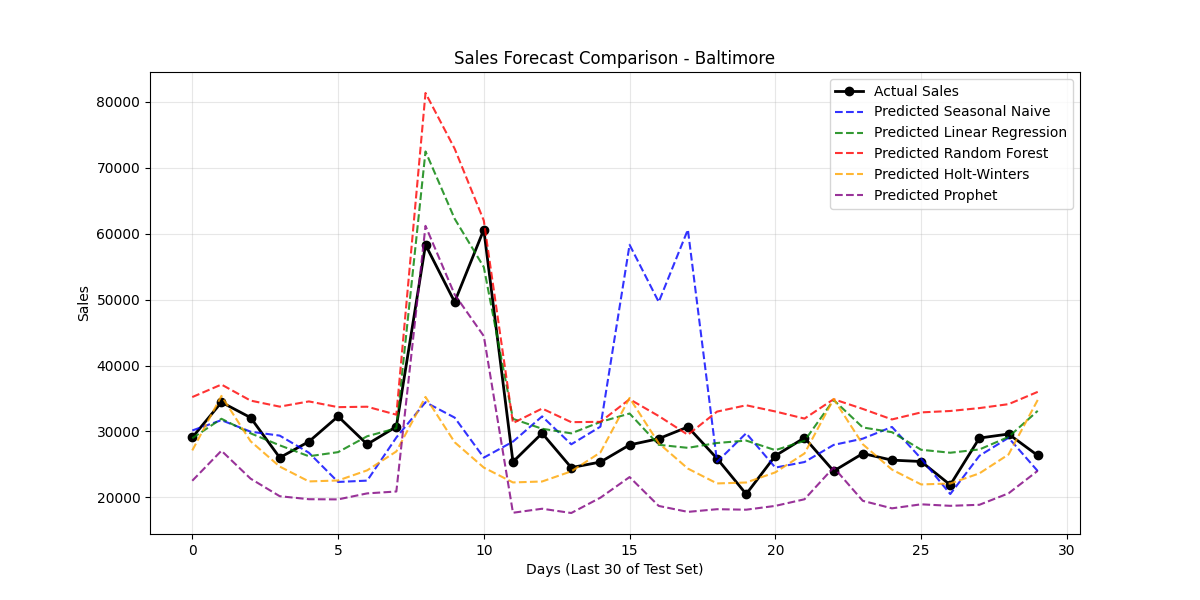

In [8]:
from IPython.display import Image, display
print("### Exemplo de Previsão Final (Last 30 Days Test Set) ###")
# Podes escolher uma imagem específica para mostrar aqui
display(Image(filename='data/processed/plots/baltimore_forecast_comparison.png'))